## 5.3、5.4  PyTorchでDQNをxArm6でやる

In [1]:
# 必要なパッケージのインストール
%pip install numpy matplotlib pyrealsense2 xarm-python-sdk opencv-python sounddevice JSAnimation torch torchvision

   ---------------------------------------- 0.0/241.3 MB ? eta -:--:--
   ---------------------------------------- 0.5/241.3 MB 2.8 MB/s eta 0:01:27
   ---------------------------------------- 1.3/241.3 MB 3.7 MB/s eta 0:01:05
   ---------------------------------------- 2.4/241.3 MB 4.3 MB/s eta 0:00:56
    --------------------------------------- 3.4/241.3 MB 4.6 MB/s eta 0:00:53
    --------------------------------------- 4.5/241.3 MB 4.5 MB/s eta 0:00:53
    --------------------------------------- 5.5/241.3 MB 4.6 MB/s eta 0:00:52
   - -------------------------------------- 6.6/241.3 MB 4.6 MB/s eta 0:00:51
   - -------------------------------------- 7.9/241.3 MB 4.8 MB/s eta 0:00:49
   - -------------------------------------- 8.7/241.3 MB 4.8 MB/s eta 0:00:49
   - -------------------------------------- 10.0/241.3 MB 4.9 MB/s eta 0:00:48
   - -------------------------------------- 11.0/241.3 MB 4.9 MB/s eta 0:00:47
   -- ------------------------------------- 12.3/241.3 MB 5.0 MB/s et


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# パッケージのimport
import numpy as np
import matplotlib.pyplot as plt
import pyrealsense2 as rs
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import time
from xarm.wrapper import XArmAPI
import sounddevice as sd
import torch


SDK_VERSION: 1.15.3


In [16]:
# 動画の描画関数の宣言
# 参考URL http://nbviewer.jupyter.org/github/patrickmineault
# /xcorr-notebooks/blob/master/Render%20OpenAI%20gym%20as%20GIF.ipynb
from JSAnimation.IPython_display import display_animation
from matplotlib import animation
from IPython.display import display


def display_frames_as_gif(frames):
    """
    Displays a list of frames as a gif, with controls
    """
    plt.figure(figsize=(frames[0].shape[1]/72.0, frames[0].shape[0]/72.0),
               dpi=72)
    patch = plt.imshow(frames[0])
    plt.axis('off')

    def animate(i):
        patch.set_data(frames[i])

    anim = animation.FuncAnimation(plt.gcf(), animate, frames=len(frames),
                                   interval=50)

    anim.save('movie_cartpole_DQN.mp4')  # 動画のファイル名と保存です
    display(display_animation(anim, default_mode='loop'))
    

In [4]:
# 本コードでは、namedtupleを使用します。
# namedtupleを使うことで、値をフィールド名とペアで格納できます。
# すると値に対して、フィールド名でアクセスできて便利です。
# https://docs.python.jp/3/library/collections.html#collections.namedtuple
# 以下は使用例です

from collections import namedtuple

Tr = namedtuple('tr', ('name_a', 'value_b'))
Tr_object = Tr('名前Aです', 100)

print(Tr_object)  # 出力：tr(name_a='名前Aです', value_b=100)
print(Tr_object.value_b)  # 出力：100


tr(name_a='名前Aです', value_b=100)
100


In [5]:
# namedtupleを生成
from collections import namedtuple

Transition = namedtuple(
    'Transition', ('state', 'action', 'next_state', 'reward'))


In [6]:
# 定数の設定
GAMMA = 0.99  # 時間割引率
MAX_STEPS = 200  # 1試行のstep数
NUM_EPISODES = 500  # 最大試行回数

# ロボットの定数の設定
MAX_TCP_SPEED = 400  # mm/s
MIN_CART_POS = -0.22
MAX_CART_POS = 0.22
MAX_CART_VEL = MAX_TCP_SPEED / 1000.
MAX_POLE_ANGLE = 0.87   # 約50度
MAX_POL_VEL = 2.

In [7]:
# 経験を保存するメモリクラスを定義します


class ReplayMemory:

    def __init__(self, CAPACITY):
        self.capacity = CAPACITY  # メモリの最大長さ
        self.memory = []  # 経験を保存する変数
        self.index = 0  # 保存するindexを示す変数

    def push(self, state, action, state_next, reward):
        '''transition = (state, action, state_next, reward)をメモリに保存する'''

        if len(self.memory) < self.capacity:
            self.memory.append(None)  # メモリが満タンでないときは足す

        # namedtupleのTransitionを使用し、値とフィールド名をペアにして保存します
        self.memory[self.index] = Transition(state, action, state_next, reward)

        self.index = (self.index + 1) % self.capacity  # 保存するindexを1つずらす

    def sample(self, batch_size):
        '''batch_size分だけ、ランダムに保存内容を取り出す'''
        return random.sample(self.memory, batch_size)

    def __len__(self):
        '''関数lenに対して、現在の変数memoryの長さを返す'''
        return len(self.memory)


In [8]:
# エージェントが持つ脳となるクラスです、DQNを実行します
# Q関数をディープラーニングのネットワークをクラスとして定義

import random
import torch
from torch import nn
from torch import optim
import torch.nn.functional as F

BATCH_SIZE = 32
CAPACITY = 10000


class Brain:
    def __init__(self, num_states, num_actions):
        self.num_actions = num_actions  # CartPoleの行動（右に左に押す）の2を取得

        # 経験を記憶するメモリオブジェクトを生成
        self.memory = ReplayMemory(CAPACITY)

        # ニューラルネットワークを構築
        self.model = nn.Sequential()
        self.model.add_module('fc1', nn.Linear(num_states, 32))
        self.model.add_module('relu1', nn.ReLU())
        self.model.add_module('fc2', nn.Linear(32, 32))
        self.model.add_module('relu2', nn.ReLU())
        self.model.add_module('fc3', nn.Linear(32, num_actions))

        print(self.model)  # ネットワークの形を出力

        # 最適化手法の設定
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.0001)

    def replay(self):
        '''Experience Replayでネットワークの結合パラメータを学習'''

        # -----------------------------------------
        # 1. メモリサイズの確認
        # -----------------------------------------
        # 1.1 メモリサイズがミニバッチより小さい間は何もしない
        if len(self.memory) < BATCH_SIZE:
            return

        # -----------------------------------------
        # 2. ミニバッチの作成
        # -----------------------------------------
        # 2.1 メモリからミニバッチ分のデータを取り出す
        transitions = self.memory.sample(BATCH_SIZE)

        # 2.2 各変数をミニバッチに対応する形に変形
        # transitionsは1stepごとの(state, action, state_next, reward)が、BATCH_SIZE分格納されている
        # つまり、(state, action, state_next, reward)×BATCH_SIZE
        # これをミニバッチにしたい。つまり
        # (state×BATCH_SIZE, action×BATCH_SIZE, state_next×BATCH_SIZE, reward×BATCH_SIZE)にする
        batch = Transition(*zip(*transitions))

        # 2.3 各変数の要素をミニバッチに対応する形に変形し、ネットワークで扱えるようVariableにする
        # 例えばstateの場合、[torch.FloatTensor of size 1x4]がBATCH_SIZE分並んでいるのですが、
        # それを torch.FloatTensor of size BATCH_SIZEx4 に変換します
        # 状態、行動、報酬、non_finalの状態のミニバッチのVariableを作成
        # catはConcatenates（結合）のことです。
        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)
        non_final_next_states = torch.cat([s for s in batch.next_state
                                           if s is not None])

        # -----------------------------------------
        # 3. 教師信号となるQ(s_t, a_t)値を求める
        # -----------------------------------------
        # 3.1 ネットワークを推論モードに切り替える
        self.model.eval()

        # 3.2 ネットワークが出力したQ(s_t, a_t)を求める
        # self.model(state_batch)は、右左の両方のQ値を出力しており
        # [torch.FloatTensor of size BATCH_SIZEx2]になっている。
        # ここから実行したアクションa_tに対応するQ値を求めるため、action_batchで行った行動a_tが右か左かのindexを求め
        # それに対応するQ値をgatherでひっぱり出す。
        state_action_values = self.model(state_batch).gather(1, action_batch)

        # 3.3 max{Q(s_t+1, a)}値を求める。ただし次の状態があるかに注意。

        # cartpoleがdoneになっておらず、next_stateがあるかをチェックするインデックスマスクを作成
        non_final_mask = torch.ByteTensor(tuple(map(lambda s: s is not None,
                                                    batch.next_state)))
        # まずは全部0にしておく
        next_state_values = torch.zeros(BATCH_SIZE)

        # 次の状態があるindexの最大Q値を求める
        # 出力にアクセスし、max(1)で列方向の最大値の[値、index]を求めます
        # そしてそのQ値（index=0）を出力します
        # detachでその値を取り出します
        next_state_values[non_final_mask] = self.model(
            non_final_next_states).max(1)[0].detach()

        # 3.4 教師となるQ(s_t, a_t)値を、Q学習の式から求める
        expected_state_action_values = reward_batch + GAMMA * next_state_values

        # -----------------------------------------
        # 4. 結合パラメータの更新
        # -----------------------------------------
        # 4.1 ネットワークを訓練モードに切り替える
        self.model.train()

        # 4.2 損失関数を計算する（smooth_l1_lossはHuberloss）
        # expected_state_action_valuesは
        # sizeが[minbatch]になっているので、unsqueezeで[minibatch x 1]へ
        loss = F.smooth_l1_loss(state_action_values,
                                expected_state_action_values.unsqueeze(1))

        # 4.3 結合パラメータを更新する
        self.optimizer.zero_grad()  # 勾配をリセット
        loss.backward()  # バックプロパゲーションを計算
        self.optimizer.step()  # 結合パラメータを更新

    def decide_action(self, state, episode):
        '''現在の状態に応じて、行動を決定する'''
        # ε-greedy法で徐々に最適行動のみを採用する
        epsilon = 0.5 * (1 / (episode + 1))

        if epsilon <= np.random.uniform(0, 1):
            self.model.eval()  # ネットワークを推論モードに切り替える
            with torch.no_grad():
                action = self.model(state).max(1)[1].view(1, 1)
            # ネットワークの出力の最大値のindexを取り出します = max(1)[1]
            # .view(1,1)は[torch.LongTensor of size 1]　を size 1x1 に変換します

        else:
            # 0,1の行動をランダムに返す
            action = torch.LongTensor(
                [[random.randrange(self.num_actions)]])  # 0,1の行動をランダムに返す
            # actionは[torch.LongTensor of size 1x1]の形になります

        return action


In [11]:
# CartPoleで動くエージェントクラスです、棒付き台車そのものになります


class Agent:
    def __init__(self, brain):
        '''課題の状態と行動の数を設定する'''
        self.brain = brain  # エージェントが行動を決定するための頭脳を生成

    def update_q_function(self):
        '''Q関数を更新する'''
        self.brain.replay()

    def get_action(self, state, episode):
        '''行動を決定する'''
        action = self.brain.decide_action(state, episode)
        return action

    def memorize(self, state, action, state_next, reward):
        '''memoryオブジェクトに、state, action, state_next, rewardの内容を保存する'''
        self.brain.memory.push(state, action, state_next, reward)


In [ ]:
class RobotEnvironment:
    '''CartPoleを模したロボット環境クラスです、xArm6とRealSenseを用いて実装します'''

    def __init__(self):
        self.step_num = 0  # ステップ数
        self.last_time = time.perf_counter()  # フレームレート計測用の変数
        self.last_cart_pos = 0.0  # 台車の前回位置 [m]
        self.last_pole_angle = 0.0  # 棒の前回角度 [rad]
        self.image_bgr = None  # BGR画像

    def reset(self):
        '''CartPole環境のリセット'''
        # realsenseパイプラインの停止
        self.pipeline.stop()

        # 1回チャイム音を鳴らす（人にロボットをリセットさせる合図）
        self._play_down_chime()
        # リセットされるまで待つwait
        time.sleep(1)

        self.step_num = 0  # ステップ数をリセット
        self.arm.set_position(x=360, y=0, z=370, roll=120, pitch=-90, yaw=60, speed=200, is_radian=False, wait=False)
        time.sleep(2)

        # realsenseパイプラインの再開
        self._init_rs()

        # チャイム音を鳴らす（人にロボットが動き始めることを知らせる合図）
        self._play_up_chime()

        self.last_time = time.perf_counter()  # フレームレート計測用の変数
        observation = self.observation()
        return observation
    
    def _init_rs(self):
        '''Realsenseの初期化'''
        # RealSenseパイプラインの設定
        self.pipeline = rs.pipeline()
        config = rs.config()

        # RGBとDepthストリームを有効にする
        config.enable_stream(rs.stream.depth, 424, 240, rs.format.z16, 60)
        config.enable_stream(rs.stream.color, 424, 240, rs.format.bgr8, 60)

        # ストリーミング開始
        self.pipeline.start(config)

        # レーザー出力調整
        profile = self.pipeline.get_active_profile()
        device = profile.get_device()
        depth_sensor = device.first_depth_sensor()
        
        if depth_sensor.supports(rs.option.laser_power):
            depth_sensor.set_option(rs.option.laser_power, 80)  # 低出力

        # アライメント設定（DepthをRGBに合わせる）
        align_to = rs.stream.color
        self.align = rs.align(align_to)

        # 1フレーム取得
        frames = self.pipeline.wait_for_frames()
        
        # フレームをアライメント
        aligned_frames = self.align.process(frames)
        
        # RGB画像Depth画像を取得
        depth_frame = aligned_frames.get_depth_frame()

        # カメラの内部パラメータを取得
        self.depth_intrin = depth_frame.profile.as_video_stream_profile().intrinsics

    def _init_xarm(self):
        '''xArm6の初期化'''
        self.arm = XArmAPI("192.168.0.244", is_radian=True)

        if self.arm.warn_code != 0:
            self.arm.clean_warn()
        if self.arm.error_code != 0:
            self.arm.clean_error()
            
        self.arm.motion_enable(enable=True)
        self.arm.set_mode(7) # online cartesian mode
        self.arm.set_state(state=0)

        self.arm.set_position(x=360, y=0, z=370, roll=120, pitch=-90, yaw=60, speed=100, is_radian=False, wait=False)
        time.sleep(3)

    def initialize(self):
        '''CartPole環境の初期化'''
        self._init_rs()
        self._init_xarm()
    
    def wait_observation(self):
        # Realsenseから画像を取得
        # フレーム取得
        return self.pipeline.wait_for_frames()
    
    def observation(self):
        '''CartPole環境の観測'''
        # 返す変数
        cart_pos: float = 0.0   # 台車の位置 [m]
        cart_vel: float = 0.0   # 台車の速度 [m/s]
        pole_angle: float = 0.0 # 棒の角度 [rad]
        pole_vel: float = 0.0   # 棒の角速度 [rad/s]

        # フレーム取得
        frames = self.pipeline.wait_for_frames()
        current_time = current_time = time.perf_counter()
        elapsed_time = current_time - self.last_time
        
        # 速度計算

        # フレームをアライメント
        aligned_frames = self.align.process(frames)
        
        # RGB画像とDepth画像を取得
        color_frame = aligned_frames.get_color_frame()
        depth_frame = aligned_frames.get_depth_frame()

        if not color_frame or not depth_frame:
            return None
        
        # NumPy配列に変換
        color_image = np.asanyarray(color_frame.get_data())
        self.image_bgr = color_image

        # 朱色の点を検出
        hsv_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2HSV)
        lower_orange = np.array([0, 190, 120])
        upper_orange = np.array([15, 255, 180])
        mask_orange = cv2.inRange(hsv_image, lower_orange, upper_orange)

        # 閾値以下のサイズのノイズを除去
        kernel = np.ones((3, 3), np.uint8)
        mask_orange = cv2.morphologyEx(mask_orange, cv2.MORPH_OPEN, kernel)
        mask_orange = cv2.morphologyEx(mask_orange, cv2.MORPH_CLOSE, kernel)
        contours_orange, _ = cv2.findContours(mask_orange, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # 緑色の点を検出
        hsv_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2HSV)
        lower_green = np.array([65, 225, 50])
        upper_green = np.array([80, 255, 110])
        mask_green = cv2.inRange(hsv_image, lower_green, upper_green)

        # 閾値以下のサイズのノイズを除去
        kernel = np.ones((3, 3), np.uint8)
        mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_OPEN, kernel)
        mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_CLOSE, kernel)
        contours_green, _ = cv2.findContours(mask_green, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # 3D座標
        green_point_3d = None
        orange_point_3d = None

        if contours_orange:
            # 最大の輪郭を取得
            largest_contour = max(contours_orange, key=cv2.contourArea)

            # 輪郭の中心を計算
            M = cv2.moments(largest_contour)
            if M["m00"] != 0:
                center_x = int(M["m10"] / M["m00"])
                center_y = int(M["m01"] / M["m00"])
                
                # 深度値を取得
                depth_value = depth_frame.get_distance(center_x, center_y)
                
                if depth_value > 0:
                    # 3D座標に変換
                    depth_intrin = depth_frame.profile.as_video_stream_profile().intrinsics
                    point_3d = rs.rs2_deproject_pixel_to_point(
                        depth_intrin, [center_x, center_y], depth_value
                    )
                    orange_point_3d = point_3d

                    #print(f"朱色の点の3D座標: x={orange_point_3d[0]:.3f}m, y={orange_point_3d[1]:.3f}m, z={orange_point_3d[2]:.3f}m")
                    cart_pos = orange_point_3d[0]  # 台車の位置 [m]
                    if elapsed_time > 0:  # ゼロ除算対策
                        cart_vel = (cart_pos - self.last_cart_pos) / elapsed_time  # 台車の速度 [m/s]
                    else:
                        cart_vel = 0.0
                    self.last_cart_pos = cart_pos  # 台車の前回位置を更新
                else:
                    print("有効な深度値が取得できませんでした")

        if contours_green:
            # 最大の輪郭を取得
            largest_contour = max(contours_green, key=cv2.contourArea)

            # 輪郭の中心を計算
            M = cv2.moments(largest_contour)
            if M["m00"] != 0:
                center_x = int(M["m10"] / M["m00"])
                center_y = int(M["m01"] / M["m00"])
                
                # 深度値を取得
                depth_value = depth_frame.get_distance(center_x, center_y)
                
                if depth_value > 0:
                    # 3D座標に変換
                    depth_intrin = depth_frame.profile.as_video_stream_profile().intrinsics
                    point_3d = rs.rs2_deproject_pixel_to_point(
                        depth_intrin, [center_x, center_y], depth_value
                    )
                    green_point_3d = point_3d

                    #print(f"緑色の点の3D座標: x={green_point_3d[0]:.3f}m, y={green_point_3d[1]:.3f}m, z={green_point_3d[2]:.3f}m")
                else:
                    print("有効な深度値が取得できませんでした")
        
        if orange_point_3d is not None and green_point_3d is not None:
            # 朱色の点と緑色の点の2D座標を取得
            orange_2d = np.array([-orange_point_3d[1], -orange_point_3d[0]])
            green_2d = np.array([-green_point_3d[1], -green_point_3d[0]])
            
            # 2Dベクトルを計算
            vector = green_2d - orange_2d
            
            # 角度を計算（atan2を使用して反時計回りを正とする）
            angle_rad = np.arctan2(vector[1], vector[0])
            angle_deg = np.degrees(angle_rad)
            
            pole_angle = angle_rad  # 棒の角度 [rad]
            if elapsed_time > 0:  # ゼロ除算対策
                pole_vel = (pole_angle - self.last_pole_angle) / elapsed_time  # 棒の角速度 [rad/s]
            else:
                pole_vel = 0.0
            self.last_pole_angle = pole_angle  # 棒の前回角度を更新

        print(f"フレームレート: {1/(current_time - self.last_time):.1f} FPS")
        self.last_time = current_time  # フレームレート計測用の変数を更新
        self.step_num += 1

        observation = np.array([cart_pos, cart_vel, pole_angle, pole_vel])
        return observation
    
    def get_image(self):
        # BGR to RGB変換（matplotlib用）
        color_image_rgb = cv2.cvtColor(self.image_bgr, cv2.COLOR_BGR2RGB)
        return color_image_rgb

    def step(self, action):
        '''CartPole環境の1ステップ実行'''
        # xArm6を動かす
        if action == 0:
            self.arm.set_position(x=360, y=240, z=370, roll=120, pitch=-90, yaw=60, speed=MAX_TCP_SPEED, is_radian=False, wait=False)
        else:
            self.arm.set_position(x=360, y=-240, z=370, roll=120, pitch=-90, yaw=60, speed=MAX_TCP_SPEED, is_radian=False, wait=False)

        # 環境の観測
        observation = self.observation()

        # 終了判定
        done = bool(
            observation[0] < MIN_CART_POS         # [m]
            or observation[0] > MAX_CART_POS      # [m]
            or observation[2] < -MAX_POLE_ANGLE   # 約-50度
            or observation[2] > MAX_POLE_ANGLE    # 約50度
        )
        if self.step_num >= MAX_STEPS:
            done = True

        # 報酬の設定
        if done and bool(
            observation[2] > -0.26      # -15度
            and observation[2] < 0.26   # 15度
            ):
            reward = 1.0
        else:
            reward = 0.0

        info = {}

        return observation, reward, done, info

    def _play_beep(self, frequency=800, duration=0.5, sample_rate=44100):
        """ビープ音を再生"""
        t = np.linspace(0, duration, int(sample_rate * duration), False)
        wave = np.sin(frequency * 2 * np.pi * t)
        sd.play(wave, sample_rate)
        sd.wait()  # 音の再生完了まで待機

    def _play_up_chime(self):
        """チャイム音を再生（複数の音程）"""
        frequencies = [523, 659, 784, 1047]  # C, E, G, C (ドミソド)
        for freq in frequencies:
            self._play_beep(freq, 0.3)

    def _play_down_chime(self):
        """チャイム音を再生（複数の音程）"""
        frequencies = [1047, 784, 659, 523]  # C, E, G, C (ドミソド)
        for freq in frequencies:
            self._play_beep(freq, 0.3)

In [12]:
num_states = 4  # cart_pos, cart_vel, pole_angle, pole_vel の4変数
num_actions = 2  # CartPoleの行動（右に左に押す）の2を取得
brain1 = Brain(num_states, num_actions)

Sequential(
  (fc1): Linear(in_features=4, out_features=32, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=2, bias=True)
)


In [ ]:
# CartPoleを実行する環境のクラスです


class Environment:

    def __init__(self):
        self.agent = Agent(brain1)  # 環境内で行動するAgentを生成
        self.robot_env = RobotEnvironment()  # ロボット環境を生成
        
    def run(self):
        '''実行'''
        episode_10_list = np.zeros(10)  # 10試行分の立ち続けたstep数を格納し、平均ステップ数を出力に利用
        complete_episodes = 0  # 195step以上連続で立ち続けた試行数
        episode_final = False  # 最後の試行フラグ
        frames = []  # 最後の試行を動画にするために画像を格納する変数

        self.robot_env.initialize()  # ロボット環境の初期化

        for episode in range(NUM_EPISODES):  # 最大試行数分繰り返す
            observation = self.robot_env.reset()  # 環境の初期化

            state = observation  # 観測をそのまま状態sとして使用
            state = torch.from_numpy(state).type(
                torch.FloatTensor)  # NumPy変数をPyTorchのテンソルに変換
            state = torch.unsqueeze(state, 0)  # size 4をsize 1x4に変換

            for step in range(MAX_STEPS):  # 1エピソードのループ

                if episode_final is True:  # 最終試行ではframesに各時刻の画像を追加していく
                    frames.append(self.robot_env.get_image())

                action = self.agent.get_action(state, episode)  # 行動を求める

                # 行動a_tの実行により、s_{t+1}とdoneフラグを求める
                # actionから.item()を指定して、中身を取り出す
                observation_next, _, done, _ = self.robot_env.step(
                    action.item())  # rewardとinfoは使わないので_にする

                # 報酬を与える。さらにepisodeの終了評価と、state_nextを設定する
                if done:  # ステップ数が200経過するか、一定角度以上傾くとdoneはtrueになる
                    state_next = None  # 次の状態はないので、Noneを格納

                    # 直近10episodeの立てたstep数リストに追加
                    episode_10_list = np.hstack(
                        (episode_10_list[1:], step + 1))

                    if step < 195:
                        reward = torch.FloatTensor(
                            [-1.0])  # 途中でこけたら罰則として報酬-1を与える
                        complete_episodes = 0  # 連続成功記録をリセット
                    else:
                        reward = torch.FloatTensor([1.0])  # 立ったまま終了時は報酬1を与える
                        complete_episodes = complete_episodes + 1  # 連続記録を更新
                else:
                    reward = torch.FloatTensor([0.0])  # 普段は報酬0
                    state_next = observation_next  # 観測をそのまま状態とする
                    state_next = torch.from_numpy(state_next).type(
                        torch.FloatTensor)  # numpy変数をPyTorchのテンソルに変換
                    state_next = torch.unsqueeze(state_next, 0)  # size 4をsize 1x4に変換

                # メモリに経験を追加
                self.agent.memorize(state, action, state_next, reward)

                # Experience ReplayでQ関数を更新する
                self.agent.update_q_function()

                # 観測の更新
                state = state_next

                # 終了時の処理
                if done:
                    print('%d Episode: Finished after %d steps：10試行の平均step数 = %.1lf' % (
                        episode, step + 1, episode_10_list.mean()))
                    break

            if episode_final is True:
                # 動画を保存と描画
                display_frames_as_gif(frames)
                break

            # 10連続で200step立ち続けたら成功
            if complete_episodes >= 10:
                print('10回連続成功')
                episode_final = True  # 次の試行を描画を行う最終試行とする


ROBOT_IP: 192.168.0.244, VERSION: v2.6.0, PROTOCOL: V1, DETAIL: 6,6,XI1100,XX0000,v2.6.0, TYPE1300: [0, 0]
change protocol identifier to 3
[motion_enable], xArm is not ready to move
[set_state], xArm is ready to move
フレームレート: 22988.5 FPS
フレームレート: 36.3 FPS
フレームレート: 126.5 FPS
フレームレート: 110.5 FPS
フレームレート: 57.3 FPS
フレームレート: 62.1 FPS
フレームレート: 59.6 FPS
フレームレート: 59.2 FPS
フレームレート: 58.4 FPS
フレームレート: 59.3 FPS
フレームレート: 48.8 FPS
フレームレート: 79.8 FPS
フレームレート: 59.0 FPS
フレームレート: 57.7 FPS
フレームレート: 59.5 FPS
フレームレート: 59.5 FPS
フレームレート: 60.3 FPS
フレームレート: 58.7 FPS
フレームレート: 60.9 FPS
フレームレート: 60.0 FPS
フレームレート: 60.5 FPS
フレームレート: 58.5 FPS
フレームレート: 60.1 FPS
フレームレート: 58.3 FPS
フレームレート: 60.2 FPS
フレームレート: 58.7 FPS
フレームレート: 60.3 FPS
フレームレート: 58.0 FPS
フレームレート: 59.0 FPS
フレームレート: 61.7 FPS
フレームレート: 59.6 FPS
フレームレート: 60.2 FPS
フレームレート: 59.1 FPS
フレームレート: 52.1 FPS
フレームレート: 69.7 FPS
フレームレート: 58.5 FPS
フレームレート: 59.6 FPS
フレームレート: 59.0 FPS
フレームレート: 57.2 FPS
フレームレート: 63.8 FPS


C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_15428\609345531.py:93: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen/native/IndexingUtils.h:30.)
  next_state_values[non_final_mask] = self.model(


フレームレート: 58.9 FPS
フレームレート: 58.1 FPS
フレームレート: 61.3 FPS
フレームレート: 57.5 FPS
フレームレート: 61.8 FPS
フレームレート: 60.3 FPS
フレームレート: 57.5 FPS
フレームレート: 61.0 FPS
フレームレート: 59.6 FPS
フレームレート: 59.6 FPS
フレームレート: 59.7 FPS
フレームレート: 59.6 FPS
フレームレート: 58.2 FPS
フレームレート: 61.0 FPS
フレームレート: 58.5 FPS
フレームレート: 59.9 FPS
フレームレート: 57.3 FPS
フレームレート: 62.3 FPS
フレームレート: 59.0 FPS
フレームレート: 61.2 FPS
フレームレート: 59.2 FPS
フレームレート: 59.7 FPS
フレームレート: 58.9 FPS
フレームレート: 59.3 FPS
フレームレート: 59.5 FPS
フレームレート: 59.1 FPS
フレームレート: 60.7 FPS
フレームレート: 59.1 FPS
フレームレート: 59.4 FPS
フレームレート: 59.3 FPS
フレームレート: 60.5 FPS
フレームレート: 58.7 FPS
フレームレート: 59.7 FPS
フレームレート: 59.8 FPS
フレームレート: 58.0 FPS
フレームレート: 61.1 FPS
フレームレート: 59.5 FPS
フレームレート: 58.7 FPS
フレームレート: 59.5 FPS
フレームレート: 59.1 FPS
フレームレート: 59.3 FPS
フレームレート: 60.5 FPS
フレームレート: 59.6 FPS
フレームレート: 59.5 FPS
フレームレート: 58.2 FPS
フレームレート: 61.8 FPS
フレームレート: 58.5 FPS
フレームレート: 60.6 FPS
フレームレート: 59.4 FPS
フレームレート: 59.6 FPS
フレームレート: 59.9 FPS
フレームレート: 59.0 FPS
フレームレート: 57.7 FPS
フレームレート: 25.2 FPS
フレームレート: 122.6 FPS
フレームレート: 

MovieWriter ffmpeg unavailable; using Pillow instead.


ValueError: unknown file extension: .mp4

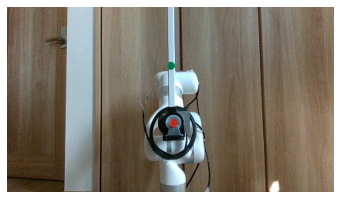

ControllerError, code: 1


In [14]:
# main クラス
cartpole_env = Environment()
cartpole_env.run()
